In [ ]:
import os

dataset_path = "C:/Users/pc/Desktop/Emotion_detector/animal detection/dataset/animals"

classes = [
    "Bear",
    "Deer",
    "Duck",
    "Fox",
    "Parrot",
    "Rabbit",
    "Raccoon",
    "Red Panda",
    "Squirrel",
    "Tiger"
]

print("Dataset:", os.path.exists(dataset_path))
print("Classes:", len(classes))
print(classes)

Dataset: True
Classes: 10
['Bear', 'Deer', 'Duck', 'Fox', 'Parrot', 'Rabbit', 'Raccoon', 'Red Panda', 'Squirrel', 'Tiger']


In [ ]:
import os
import shutil
import random

source = dataset_path
output = "C:/Users/pc/Desktop/Emotion_detector/animal detection/model/animal_yolo"

os.makedirs(f"{output}/images/train", exist_ok=True)
os.makedirs(f"{output}/images/val", exist_ok=True)
os.makedirs(f"{output}/labels/train", exist_ok=True)
os.makedirs(f"{output}/labels/val", exist_ok=True)

image_extensions = (".jpg", ".jpeg", ".png")
all_data = []

for class_id, class_name in enumerate(classes):
    folder_name = "Red panda" if class_name == "Red Panda" else class_name
    folder = os.path.join(source, folder_name)

    for file in os.listdir(folder):
        if file.lower().endswith(image_extensions):
            image_path = os.path.join(folder, file)
            label_path = os.path.splitext(image_path)[0] + ".txt"

            if os.path.exists(label_path):
                all_data.append((image_path, label_path))

random.seed(42)
random.shuffle(all_data)

split = int(len(all_data) * 0.8)
train_data = all_data[:split]
val_data = all_data[split:]

for data, split_name in [(train_data, "train"), (val_data, "val")]:
    for image_path, label_path in data:
        image_name = os.path.basename(image_path)
        label_name = os.path.basename(label_path)

        shutil.copy2(
            image_path,
            f"{output}/images/{split_name}/{image_name}"
        )

        shutil.copy2(
            label_path,
            f"{output}/labels/{split_name}/{label_name}"
        )

print("Total:", len(all_data))
print("Train:", len(train_data))
print("Validation:", len(val_data))

Total: 0
Train: 0
Validation: 0


In [75]:
import os

for root, dirs, files in os.walk(dataset_path):
    print(root, "->", len(files), "files")
    if len(files) > 0:
        print(files[:5])
    if root.count(os.sep) >= dataset_path.count(os.sep) + 2:
        dirs[:] = []

/kaggle/input/datasets/giotamoraiti/animal-object-detection-dataset-10-classes/animals -> 1 files
['labels.txt']
/kaggle/input/datasets/giotamoraiti/animal-object-detection-dataset-10-classes/animals/Parrot -> 546 files
['Parrot_0360.jpg', 'Parrot_0075.jpg', 'Parrot_0012.jpg', 'Parrot_0377.jpg', 'Parrot_0049.jpg']
/kaggle/input/datasets/giotamoraiti/animal-object-detection-dataset-10-classes/animals/Parrot/labels -> 546 files
['Parrot_0402.txt', 'Parrot_0086.txt', 'Parrot_0362.txt', 'Parrot_0112.txt', 'Parrot_0194.txt']
/kaggle/input/datasets/giotamoraiti/animal-object-detection-dataset-10-classes/animals/Fox -> 424 files
['Fox_0048.jpg', 'Fox_0125.jpg', 'Fox_0326.jpg', 'Fox_0399.jpg', 'Fox_0022.jpg']
/kaggle/input/datasets/giotamoraiti/animal-object-detection-dataset-10-classes/animals/Fox/labels -> 424 files
['Fox_0327.txt', 'Fox_0104.txt', 'Fox_0128.txt', 'Fox_0419.txt', 'Fox_0396.txt']
/kaggle/input/datasets/giotamoraiti/animal-object-detection-dataset-10-classes/animals/Raccoon ->

In [ ]:
import os
import shutil
import random

source = dataset_path
output = "C:/Users/pc/Desktop/Emotion_detector/animal detection/model/animal_yolo"

os.makedirs(f"{output}/images/train", exist_ok=True)
os.makedirs(f"{output}/images/val", exist_ok=True)
os.makedirs(f"{output}/labels/train", exist_ok=True)
os.makedirs(f"{output}/labels/val", exist_ok=True)

all_data = []
image_extensions = (".jpg", ".jpeg", ".png")

for class_name in classes:
    folder_name = "Red panda" if class_name == "Red Panda" else class_name
    image_folder = os.path.join(source, folder_name)
    label_folder = os.path.join(image_folder, "labels")

    for file in os.listdir(image_folder):
        if file.lower().endswith(image_extensions):
            image_path = os.path.join(image_folder, file)
            label_path = os.path.join(
                label_folder,
                os.path.splitext(file)[0] + ".txt"
            )

            if os.path.exists(label_path):
                all_data.append((image_path, label_path))

random.seed(42)
random.shuffle(all_data)

split = int(len(all_data) * 0.8)

train_data = all_data[:split]
val_data = all_data[split:]

for data, split_name in [(train_data, "train"), (val_data, "val")]:
    for image_path, label_path in data:
        shutil.copy2(
            image_path,
            os.path.join(output, "images", split_name, os.path.basename(image_path))
        )
        shutil.copy2(
            label_path,
            os.path.join(output, "labels", split_name, os.path.basename(label_path))
        )

print("Total:", len(all_data))
print("Train:", len(train_data))
print("Validation:", len(val_data))

Total: 4099
Train: 3279
Validation: 820


In [ ]:
import yaml

data_yaml = {
    "path": output,
    "train": "images/train",
    "val": "images/val",
    "nc": 10,
    "names": classes
}

yaml_path = "C:/Users/pc/Desktop/Emotion_detector/animal detection/model/animal_yolo/data.yaml"

with open(yaml_path, "w") as f:
    yaml.dump(data_yaml, f, sort_keys=False)

print(yaml_path)

with open(yaml_path, "r") as f:
    print(f.read())

/kaggle/working/animal_yolo/data.yaml
path: /kaggle/working/animal_yolo
train: images/train
val: images/val
nc: 10
names:
- Bear
- Deer
- Duck
- Fox
- Parrot
- Rabbit
- Raccoon
- Red Panda
- Squirrel
- Tiger



In [78]:
from ultralytics import YOLO

model = YOLO("yolo11n.yaml")

print("YOLO model created from scratch")

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
YOLO model created from scratch


In [ ]:
results = model.train(
    data=yaml_path,
    epochs=50,
    imgsz=640,
    batch=16,
    optimizer="AdamW",
    lr0=0.001,
    patience=10,
    project="C:/Users/pc/Desktop/Emotion_detector/animal detection/model/animal_detection",
    name="yolo_scratch",
    pretrained=False
)

Ultralytics 8.4.150 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/animal_yolo/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.yaml, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo_scratch, nbs=64, nms=None, opse

/usr/local/lib/python3.12/dist-packages/ray/train/_internal/session.py:676: UserWarning: `get_trial_id` is meant to only be called inside a function that is executed by a Tuner or Trainer. Returning `None`.
  warnings.warn(


       2/50       3.4G      2.253      3.845      2.742         39        640: 100% ━━━━━━━━━━━━ 205/205 2.2it/s 1:350.2sss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 26/26 1.1it/s 23.2s0.4s
                   all        820       1071     0.0421      0.206     0.0378     0.0129

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       3/50      3.41G      2.038      3.455      2.504         46        640: 100% ━━━━━━━━━━━━ 205/205 2.2it/s 1:320.2sss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 26/26 1.1it/s 23.2s0.4s
                   all        820       1071       0.19      0.149     0.0675     0.0269

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       4/50      3.41G      1.909      3.219      2.359         37        640: 100% ━━━━━━━━━━━━ 205/205 2.2it/s 1:330.2sss
                 Class     I

In [ ]:
from ultralytics import YOLO

best_model = YOLO(
    "C:/Users/pc/Desktop/Emotion_detector/animal detection/model/animal_detection/yolo_scratch/weights/best.pt"
)

print("Best model loaded")

Best model loaded



image 1/1 /kaggle/working/animal_yolo/images/val/Red panda_0314.jpg: 480x640 1 Red Panda, 7.8ms
Speed: 2.3ms preprocess, 7.8ms inference, 1.4ms postprocess per image at shape (1, 3, 480, 640)
Results saved to /kaggle/working/runs/detect/predict
Test image: /kaggle/working/animal_yolo/images/val/Red panda_0314.jpg
Result: /kaggle/working/runs/detect/predict


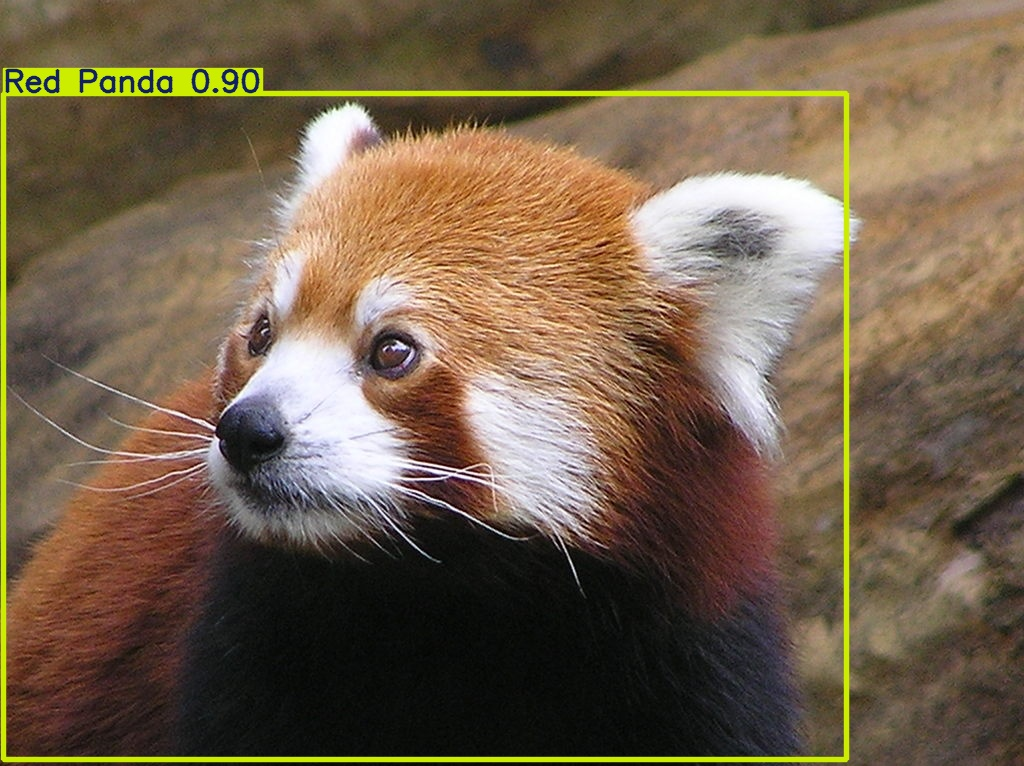

In [ ]:
import os
import random
from IPython.display import Image, display

val_images_path = "C:/Users/pc/Desktop/Emotion_detector/animal detection/model/animal_yolo/images/val"

image_files = [
    os.path.join(val_images_path, f)
    for f in os.listdir(val_images_path)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

test_image = random.choice(image_files)

results = best_model.predict(
    source=test_image,
    conf=0.25,
    save=True
)

print("Test image:", test_image)
print("Result:", results[0].save_dir)
display(Image(filename=results[0].save_dir + "/" + os.path.basename(test_image)))

Multiple-animal image: /kaggle/working/animal_yolo/images/val/Duck_0183.jpg

image 1/1 /kaggle/working/animal_yolo/images/val/Duck_0183.jpg: 576x640 3 Ducks, 52.8ms
Speed: 2.3ms preprocess, 52.8ms inference, 1.5ms postprocess per image at shape (1, 3, 576, 640)
Results saved to /kaggle/working/runs/detect/predict


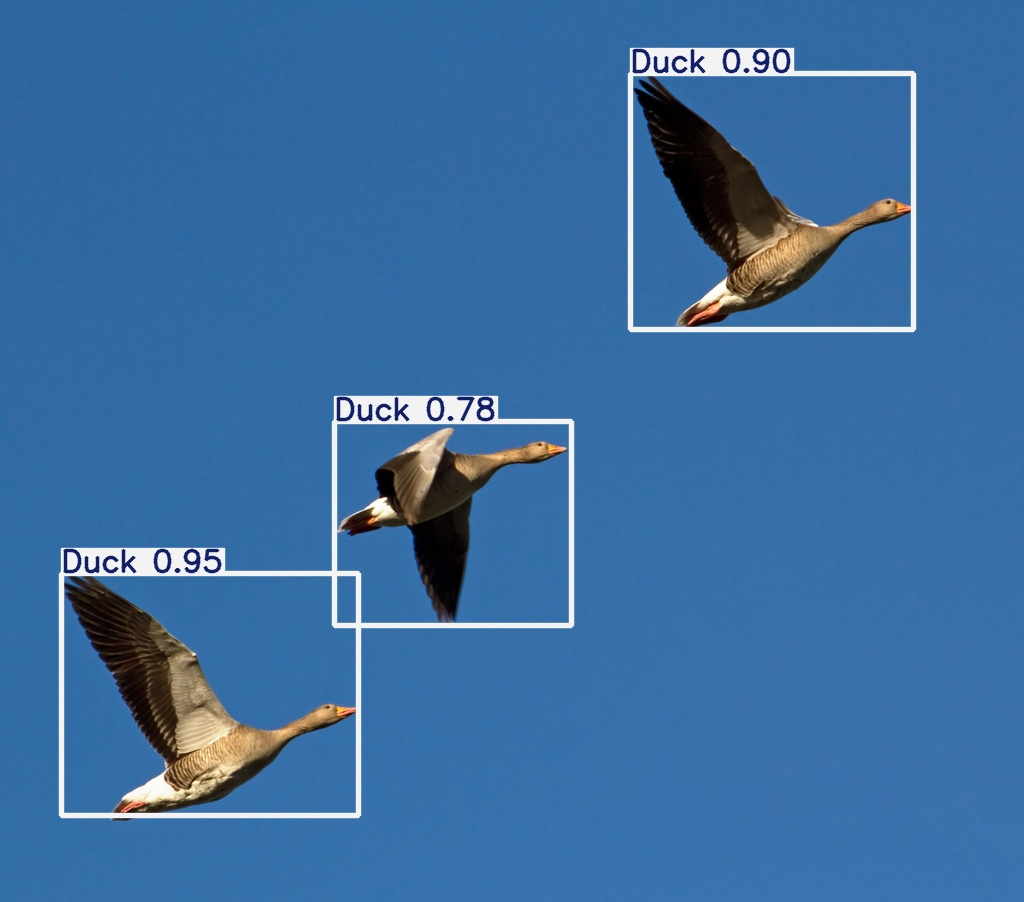

In [ ]:
multi_image = None

for image_path in image_files:
    label_path = os.path.join(
        "C:/Users/pc/Desktop/Emotion_detector/animal detection/model/animal_yolo/labels/val",
        os.path.splitext(os.path.basename(image_path))[0] + ".txt"
    )

    if os.path.exists(label_path):
        with open(label_path, "r") as f:
            lines = [line for line in f if line.strip()]

        if len(lines) >= 2:
            multi_image = image_path
            break

print("Multiple-animal image:", multi_image)

results_multi = best_model.predict(
    source=multi_image,
    conf=0.25,
    save=True
)

display(
    Image(
        filename=results_multi[0].save_dir + "/" +
        os.path.basename(multi_image)
    )
)

In [83]:
carnivores = {"Bear", "Fox", "Tiger"}

def detect_animals(image_path, conf=0.25):
    results = best_model.predict(
        source=image_path,
        conf=conf,
        verbose=False
    )

    result = results[0]
    detections = []

    for box in result.boxes:
        class_id = int(box.cls[0])
        confidence = float(box.conf[0])
        class_name = classes[class_id]

        detections.append({
            "class": class_name,
            "confidence": confidence,
            "box": box.xyxy[0].cpu().numpy().astype(int).tolist(),
            "carnivore": class_name in carnivores
        })

    return detections

detections = detect_animals(test_image)

print("Total detected:", len(detections))
print("Carnivorous animals:", sum(d["carnivore"] for d in detections))

for detection in detections:
    print(detection)

Total detected: 1
Carnivorous animals: 0
{'class': 'Red Panda', 'confidence': 0.8998504877090454, 'box': [3, 93, 846, 759], 'carnivore': False}


Total detected: 1
Carnivorous animals: 0


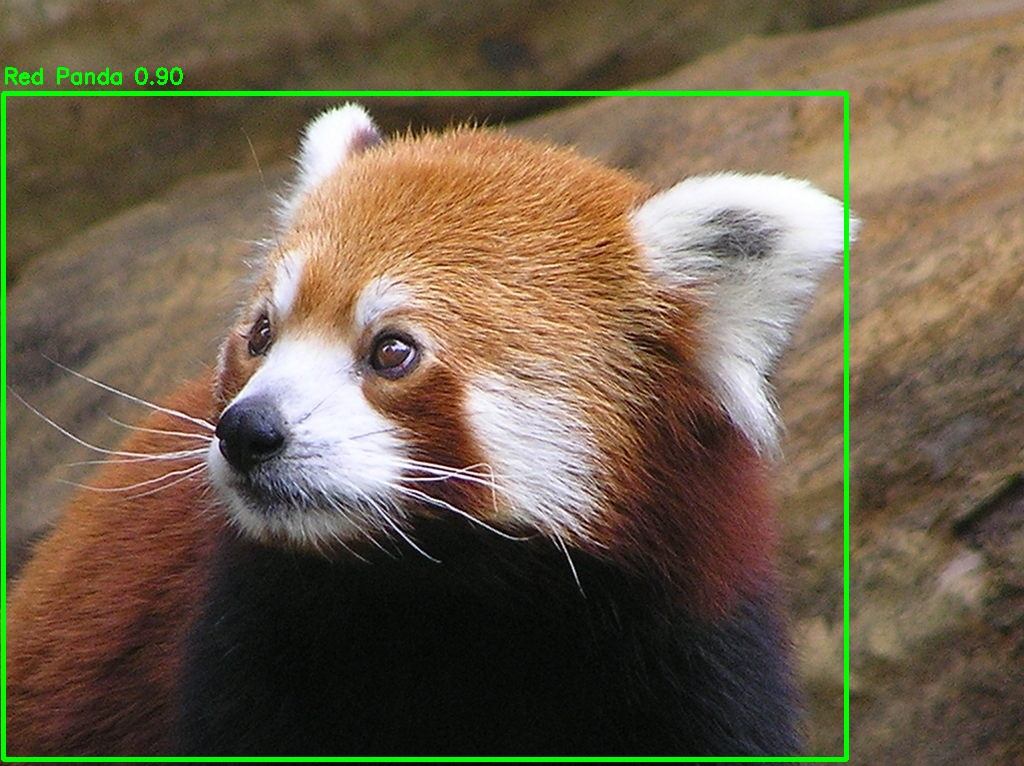

In [ ]:
import cv2
from IPython.display import display
from PIL import Image

def draw_detections(image_path, detections):
    image = cv2.imread(image_path)
    carnivore_count = 0

    for detection in detections:
        x1, y1, x2, y2 = detection["box"]
        name = detection["class"]
        confidence = detection["confidence"]

        if detection["carnivore"]:
            color = (0, 0, 255)
            carnivore_count += 1
        else:
            color = (0, 255, 0)

        cv2.rectangle(image, (x1, y1), (x2, y2), color, 3)

        text = f"{name} {confidence:.2f}"
        cv2.putText(
            image,
            text,
            (x1, max(y1 - 10, 25)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.7,
            color,
            2
        )

    output_path = "C:/Users/pc/Desktop/Emotion_detector/animal detection/model/detected_animal.jpg"
    cv2.imwrite(output_path, image)

    print("Total detected:", len(detections))
    print("Carnivorous animals:", carnivore_count)

    display(Image.open(output_path))

draw_detections(test_image, detections)

Image: /kaggle/working/animal_yolo/images/val/Tiger_0122.jpg
Total detected: 1
Carnivorous animals: 1


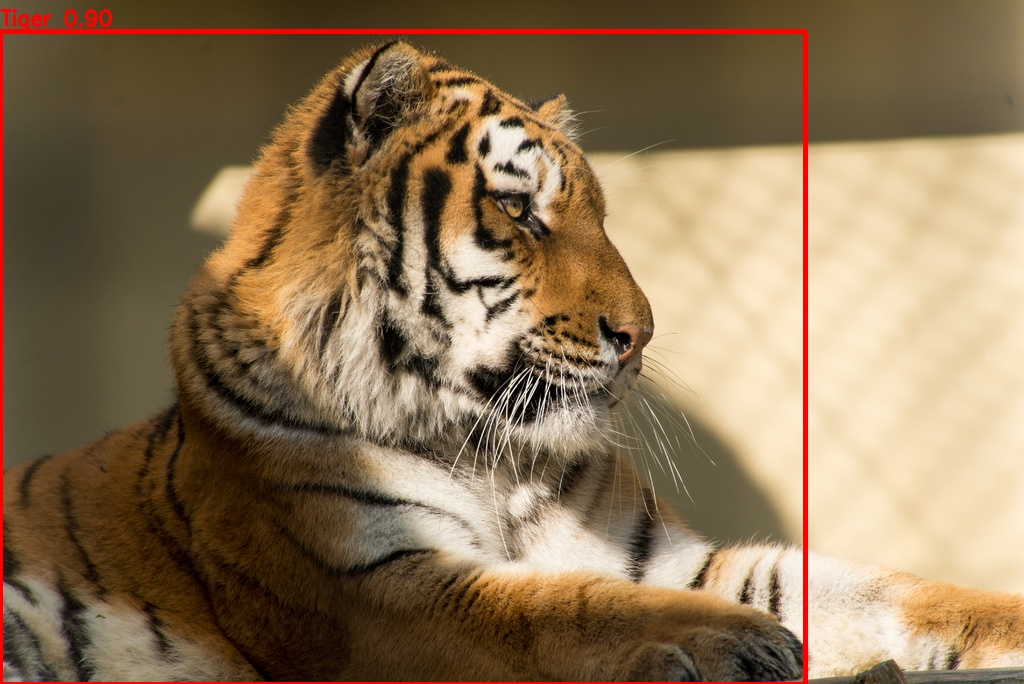

In [85]:
tiger_image = None

for image_path in image_files:
    if "Tiger_" in os.path.basename(image_path):
        tiger_image = image_path
        break

tiger_detections = detect_animals(tiger_image, conf=0.25)

print("Image:", tiger_image)
draw_detections(tiger_image, tiger_detections)

In [ ]:
import shutil
import os

source_model = "C:/Users/pc/Desktop/Emotion_detector/animal detection/model/animal_detection/yolo_scratch/weights/best.pt"
final_model = "C:/Users/pc/Desktop/Emotion_detector/animal detection/model/animal_detector_best.pt"

shutil.copy2(source_model, final_model)

print("Model:", final_model)
print("Size:", round(os.path.getsize(final_model) / (1024 * 1024), 2), "MB")

Model: /kaggle/working/animal_detector_best.pt
Size: 5.2 MB


In [ ]:
from ultralytics import YOLO

final_model_check = YOLO("C:/Users/pc/Desktop/Emotion_detector/animal detection/model/animal_detector_best.pt")

print("Model loaded successfully")
print("Classes:", final_model_check.names)

Model loaded successfully
Classes: {0: 'Bear', 1: 'Deer', 2: 'Duck', 3: 'Fox', 4: 'Parrot', 5: 'Rabbit', 6: 'Raccoon', 7: 'Red Panda', 8: 'Squirrel', 9: 'Tiger'}


In [ ]:
from ultralytics import YOLO

model_export = YOLO("C:/Users/pc/Desktop/Emotion_detector/animal detection/model/animal_detector_best.pt")

exported_path = model_export.export(
    format="saved_model",
    keras=True,
    imgsz=640
)

print("Exported:", exported_path)

Ultralytics 8.4.150 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino
YOLO11n summary (fused): 100 layers, 2,584,102 parameters, 0 gradients, 6.4 GFLOPs

PyTorch: starting from '/kaggle/working/animal_detector_best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 14, 8400) (5.2 MB)
requirements: Ultralytics requirements ['onnxruntime', 'onnxslim>=0.1.82'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 12 packages in 369ms
Prepared 2 packages in 426ms
Installed 2 packages in 14ms
 + onnxruntime==1.30.0
 + onnxslim==0.1.96

requirements: AutoUpdate success ✅ 1.4s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.22.0 opset 18...
ONNX: slimming with onnxslim 0.1.96...
ONNX: export success ✅ 3.5s, saved as '

I0000 00:00:1789288259.878369      58 devices.cc:67] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 2
I0000 00:00:1789288259.878606      58 single_machine.cc:376] Starting new session
I0000 00:00:1789288259.894485      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1789288259.896160      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
W0000 00:00:1789288260.693162      58 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1789288260.693196      58 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1789288261.531500      58 devices.cc:67] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 2
I0000 00:00:1789288261.531

TensorFlow SavedModel: export success ✅ 35.2s, saved as '/kaggle/working/animal_detector_best_saved_model' (25.3 MB)

Export complete (35.6s)
Results saved to /kaggle/working/animal_detector_best_saved_model
Predict:         yolo predict task=detect model=/kaggle/working/animal_detector_best_saved_model imgsz=640 
Validate:        yolo val task=detect model=/kaggle/working/animal_detector_best_saved_model imgsz=640 data=/kaggle/working/animal_yolo/data.yaml  
Visualize:       https://netron.app
Exported: /kaggle/working/animal_detector_best_saved_model


In [ ]:
import tensorflow as tf
from tensorflow import keras

saved_model_path = "C:/Users/pc/Desktop/Emotion_detector/animal detection/model/animal_detector_best_saved_model"

layer = keras.layers.TFSMLayer(
    saved_model_path,
    call_endpoint="serving_default"
)

inputs = keras.Input(shape=(640, 640, 3), dtype=tf.float32)
outputs = layer(inputs)

keras_model = keras.Model(inputs, outputs)

keras_path = "C:/Users/pc/Desktop/Emotion_detector/animal detection/model/animal_detector_best.keras"

keras_model.save(keras_path)

print("Keras model saved:", keras_path)

Keras model saved: /kaggle/working/animal_detector_best.keras
